# 02477 Bayesian Machine Learning 2026: Assignment 1

Written by: s210666

---

## Part 1: The beta-binomial model

### Task 1.1: Compute the prior mean of θ and provide a 95%-credibility interval for the prior.

Given the task, the prior is a uniform beta prior, with the probability:
$$
\theta \sim \text{Beta}(a_0,b_0)
$$
where $a_0=b_0=1$

which gives:
$$
\theta \sim \text{Beta}(1,1)
$$

To compute the prior mean of $\theta$ i use the formula for the mean of a beta distribution, which is given by:
$$
\mathbb{E}[\theta] = \frac{a}{a+b}
$$

By inserting the values of $a$ and $b$ into the formula, we get:
$$
\mathbb{E}[\theta] = \frac{1}{1+1}=\frac{1}{2}=0.5
$$

which is also calculated in the python code below.

In [1]:
from scipy.stats import beta

a0, b0 = 1, 1

prior_mean = a0 / (a0 + b0)

prior_mean

0.5

To provide a $95\%$-credibility interval for the prior, we use the interval defined by the $2.5\%$ and $97.5\%$ quantiles of the beta distribution, so we have:
$$
[\theta_{0.025},\ \theta_{0.975}]
$$

where $\theta_q$ satisfies $P(\theta \le \theta_q)=q$

Because $\text{Beta}(1,1)$ is $\text{uniform}(0,1)$ the CDF is therefore given by:
$$
F(\theta)=\theta \quad \text{for } \theta\in[0,1]
$$

So the quantile condition $F(\theta_q)=q$ becomes:
$$
\theta_q = q
$$

Therefore,
$$
\theta_{0.025}=0.025,\qquad \theta_{0.975}=0.975
$$

which is also calculated in the python code below.


In [2]:
ci_lower, ci_upper = beta.ppf([0.025, 0.975], a0, b0)

(ci_lower, ci_upper)

(np.float64(0.025), np.float64(0.975))

**So the prior mean is $0.5$ and the the $95\%$-credibility interval is $[0.025, 0.975]$**

### Task 1.2: Compute the posterior mean of θ and provide a 95%-credibility interval for the posterior.

To compute the posterior mean of $\theta$, where we let $y^*$ donate the number of purchases durting the next $N^* = 20$ visits, we use the formula for the beta-binomial model, where the beta prior is conjugate to the binomal likelihood and the posterior is:
$$
\theta \mid y \sim \text{Beta}(a_0+y, b_0+N-y)
$$

We insert the numbers as the following:
$$
a_{\text{posterior}} = a_0+y = 1+4 = 5
$$
$$
b_{\text{posterior}} = b_0 + N - y = 1 + 115 - 4 = 112
$$

So, 
$$
\theta \mid y \sim \text{Beta}(5,112)
$$

To compute the posterior mean of $\theta$, we use the formula for the mean of a beta distribution, which is given by:
$$
\mathbb{E}[\theta\mid y] = \frac{a_{\text{posterior}}}{a_{\text{posterior}}+b_{\text{posterior}}}
$$

Then we insert the values $a_{\text{posterior}}=5$ and $b_{\text{posterior}}=112$ and get the following posterior mean:
$$
\mathbb{E}[\theta\mid y] = \frac{5}{5+112}=\frac{5}{117}\approx 0.042735
$$

which is also calculated in the python code below.

In [3]:
a0, b0 = 1, 1
N, y = 115, 4

a_post = a0 + y
b_post = b0 + (N - y)

post_mean = a_post / (a_post + b_post)

print("Posterior: Beta({}, {})".format(a_post, b_post))
print("Posterior mean:", post_mean)

Posterior: Beta(5, 112)
Posterior mean: 0.042735042735042736


To provide a $95\%$-credibility interval for the posterior, we use again the interval defined by the $2.5\%$ and $97.5\%$ quantiles of the posterior beta distribution, so we have:
$$
[\theta_{0.025},\theta_{0.975}]
$$

where $\theta_q = F^{-1}(q)$

For $\text{Beta}(5,112)$, we calculate the quantile through python below:


In [4]:
ci_lower, ci_upper = beta.ppf([0.025, 0.975], a_post, b_post)

print("95% credible interval:", (ci_lower, ci_upper))

95% credible interval: (np.float64(0.014141556646640746), np.float64(0.08593831005795625))


**So the poster posterior mean is $\approx 0.0427$ and the the $95\%$-credibility interval is $[0.014, 0.086]$**

### Task 1.3: Compute and plot the posterior predictive distribution for $y^∗$ given $y = 4$

To compute the posterior predictive distribution $p(y^*|y=4)$, we use the posterior distribution we found in task 1.2 for $\theta$ as given:
$$
\theta \mid y \sim \text{Beta}(5,112)
$$

The predictive distribution can be found by integrating out $\theta$ as:
$$
p(y^* \mid y) = \int p(y^* \mid \theta) p(\theta \mid y) \quad d\theta
$$

Since 
$$
y^* \mid \theta \sim \text{Binomial}(N^*, \theta)
$$
and
$$
\theta \mid y \sim \text{Beta}(5,112)
$$

The predictive distribution is a beta-binomial distribution given by:
$$
y^* \mid y \sim \text{Beta-Binomial}(N^*, 5, 112)
$$


The plot of the posterior predictive distribution is shown below.

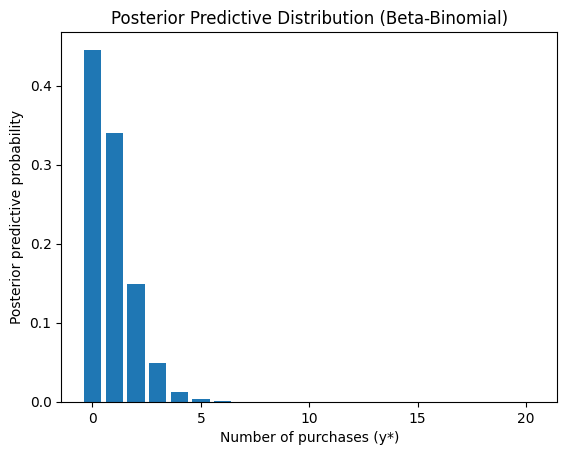

In [5]:
import numpy as np
from scipy.stats import betabinom
import matplotlib.pyplot as plt

a_post = 5
b_post = 112
N_star = 20

y_star = np.arange(0, N_star + 1)
pmf = betabinom.pmf(y_star, N_star, a_post, b_post)

plt.figure()
plt.bar(y_star, pmf)

plt.xlabel("Number of purchases (y*)")
plt.ylabel("Posterior predictive probability")
plt.title("Posterior Predictive Distribution (Beta-Binomial)")
plt.show()

### Task 1.4: What is the posterior predictive probability that at least one of the next $N^* = 20$ customers will make a purchase?

To find the posterior predictive probability that at least one of the next $N^* = 20$ customers will make a purchase, we use the predictive distribution we found in task 1.3, where we let $y^*$ denate the number of purchases during the next $N^* = 20$ visits, as following:
$$
y^* \mid y \sim \text{Beta-Binomial}(N^*, a_{\text{post}}, b_{\text{post}})
= \text{Beta-Binomial}(20,5,112)
$$

The probability that at least one customer will make a purchase is given by:
$$
P(y^* \ge 1 \mid y) = 1 - P(y^* = 0 \mid y)
$$

So, we only need $P(y^*=0\mid y)$

To compute $P(y^* = 0 \mid y)$, using the posterior predictive and conditioned on $\theta$ we have:
$$
P(y^* = 0 \mid \theta)= (1-\theta)^{N^*} = (1-\theta)^{20}
$$

Now integrate out $\theta$ using the posterior $p(\theta\mid y)$:
$$
P(y^* = 0 \mid y)=\int_0^1 (1-\theta)^{20}, p(\theta\mid y) \quad d\theta
$$

Since $p(\theta\mid y)=\text{Beta}(5,112)$, this integral has a closed form in terms of the Beta function:
$$
\begin{align*}
P(y^* = 0 \mid y) &= \frac{B(a_{\text{post}}, b_{\text{post}}+N^*)}{B(a_{\text{post}}, b_{\text{post}})} \\
&= \frac{B(5,112+20)}{B(5,112)}\\
&= \frac{B(5,132)}{B(5,112)}
\end{align*}
$$

Therefore:
$$
P(y^* \ge 1 \mid y)=1-\frac{B(5,132)}{B(5,112)}
$$

Which is calculated in the python code below.

In [6]:
p_zero = betabinom.pmf(0, N_star, a_post, b_post)
p_at_least_one = 1 - p_zero

print("P(y* = 0 | y):", p_zero)
print("P(y* >= 1 | y):", p_at_least_one)

P(y* = 0 | y): 0.4456091497355761
P(y* >= 1 | y): 0.5543908502644239


This gives:
$$
P(y^* = 0 \mid y) \approx 0.4456
$$
$$
P(y^* \ge 1 \mid y) \approx 0.5544
$$

**So the posterior predictive probability that at least one of the next $20$ customers makes a purchase is $\approx 0.554$.** 


### Task 1.5: Compute mean and variance of the posterior predictive distribution for $y^∗$

To compute the mean of the predictive distribution for $y^*$, we can use the following formula for the beta-binomial distribution for the mean:
$$
\mathbb{E}[y^* \mid y] = N^* \frac{a_{\text{posterior}}}{a_{\text{posterior}} + b_{\text{posterior}}}
$$

where we insert the values $N^* = 20$, $a_{\text{posterior}} = 5$, and $b_{\text{posterior}} = 112$ to get:
$$
\begin{align*}
\mathbb{E}[y^* \mid y] &= 20 \cdot \frac{5}{5+112} \\
&\approx 0.86
\end{align*}    
$$

which is also calculated in the python code below.

In [7]:
import numpy as np
from scipy.stats import betabinom

a_post = 5
b_post = 112
N_star = 20

predictive_mean = N_star * a_post / (a_post + b_post)

print("Posterior predictive mean:", predictive_mean)


Posterior predictive mean: 0.8547008547008547


To compute the variance of the posterior predictive distribution for $y^*$, we can use the following formula for the beta-binomial distribution for the variance:
$$  
\mathrm{Var}(y^* \mid y) = N^*\frac{a_{\text{posterior}}b_{\text{posterior}}(a_{\text{posterior}}+b_{\text{posterior}}+N^*)}{(a_{\text{posterior}}+b_{\text{posterior}})^2(a_{\text{posterior}}+b_{\text{posterior}}+1)}
$$

We then have:
$$
\begin{align*}
\mathrm{Var}(y^* \mid y) &= 20\cdot \frac{5\cdot112\cdot(5+112+20)}{(5+112)^2\cdot(5+112+1)} \\
&= 20\cdot \frac{5\cdot112\cdot137}{117^2\cdot118}
\end{align*}
$$


We now compute the numerator and denominator separately to get the variance as following:
$$
20\cdot 5\cdot112\cdot137 = 1{,}534{,}400
$$
$$
117^2\cdot118 = 1{,}615{,}302
$$

So we get the variance as following:
$$
\mathrm{Var}(y^* \mid y)=\frac{1{,}534{,}400}{1{,}615{,}302}\approx 0.9499
$$

which is also calculated in the python code below.

In [8]:
var = N_star * a_post * b_post * (a_post + b_post + N_star) / ((a_post + b_post)**2 * (a_post + b_post + 1))

print("Posterior predictive variance:", var)

Posterior predictive variance: 0.9499152480464953


**So the posterior predictive mean is $\approx 0.8547$ and the posterior predictive variance is $\approx 0.9499$.**

## Part 2: Linear Gaussian systems

### Task 2.1: Determine the distribution $p(y)$

To determine the distribution $p(y)$, we use the hint that tells to compute $p(z_2)$ first. 

So first we rewrite the $z_2 \mid z_1 \sim \mathcal{N}(z_1, vI)$ as following:
$$
z_2 = z_1 + \varepsilon_2,
\quad \varepsilon_2 \sim \mathcal{N}(0, vI),
\quad \varepsilon_2 \perp z_1
$$


### Task 2.2: Determine the distribution $p(y, z_2|z_1)$

### Task 2.3 Determine the distribution $p(y|z_1)$

### Task 2.4: Determine the distribution $p(z_1|y)$